In [2]:
from pathlib import Path

import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

data_path = Path("Backfeed_Data300.xlsx")
forward_model_path = Path("model_forward_full_pca.pth")

geometry_columns = ["L", "W", "Q", "sx", "sy", "sl", "sw"]
response_start_column = 16

raw_data = pd.read_excel(data_path, header=0)
all_geometry = raw_data.loc[:, geometry_columns].apply(
    pd.to_numeric,
    errors="raise",
)
response_db = raw_data.iloc[:, response_start_column:].apply(
    pd.to_numeric,
    errors="raise",
)
frequency = pd.to_numeric(response_db.columns, errors="raise").to_numpy()
curves_db = response_db.to_numpy(dtype=np.float32)

# L、W、Q 在当前数据中是常量，逆向模型只预测真正变化的四个尺寸。
variable_geometry_columns = [
    column
    for column in geometry_columns
    if all_geometry[column].nunique() > 1
]
constant_geometry = {
    column: float(all_geometry[column].iloc[0])
    for column in geometry_columns
    if column not in variable_geometry_columns
}
geometry = all_geometry.loc[
    :,
    variable_geometry_columns,
].to_numpy(dtype=np.float32)

all_indices = np.arange(len(raw_data))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.3,
    random_state=SEED,
    shuffle=True,
)

print(f"完整 S11 点数: {curves_db.shape[1]}")
print(f"逆向模型预测参数: {variable_geometry_columns}")
print(f"固定参数: {constant_geometry}")
print(f"训练样本={len(train_indices)}, 验证样本={len(val_indices)}")


完整 S11 点数: 1001
逆向模型预测参数: ['sx', 'sy', 'sl', 'sw']
固定参数: {'L': 39.6, 'W': 39.6, 'Q': 4.0}
训练样本=210, 验证样本=90


In [3]:
def extract_physical_features(curves, frequencies):
    features = []
    for curve in curves:
        minimum_index = int(np.argmin(curve))
        below_minus_10 = np.flatnonzero(curve <= -10)
        bandwidth = (
            frequencies[below_minus_10[-1]]
            - frequencies[below_minus_10[0]]
            if len(below_minus_10)
            else 0.0
        )
        features.append(
            [
                frequencies[minimum_index],
                curve[minimum_index],
                bandwidth,
                np.trapz(-curve, frequencies),
            ]
        )
    return np.asarray(features, dtype=np.float32)


# PCA 与标准化全部只在训练集上拟合。
inverse_pca_dim = 50
inverse_pca = PCA(n_components=inverse_pca_dim).fit(
    curves_db[train_indices]
)
pca_features = inverse_pca.transform(curves_db).astype(np.float32)
physical_features = extract_physical_features(curves_db, frequency)
inverse_features = np.column_stack(
    [pca_features, physical_features]
).astype(np.float32)

inverse_feature_scaler = StandardScaler().fit(
    inverse_features[train_indices]
)
inverse_features_scaled = inverse_feature_scaler.transform(
    inverse_features
).astype(np.float32)

# 使用 0-1 范围限制预测尺寸，避免生成训练范围之外的无效结构。
geometry_min = geometry[train_indices].min(axis=0)
geometry_max = geometry[train_indices].max(axis=0)
geometry_span = geometry_max - geometry_min
geometry_scaled = (geometry - geometry_min) / geometry_span

X_train = torch.tensor(inverse_features_scaled[train_indices])
X_val = torch.tensor(inverse_features_scaled[val_indices])
y_train = torch.tensor(geometry_scaled[train_indices])
y_val = torch.tensor(geometry_scaled[val_indices])
curve_train = torch.tensor(curves_db[train_indices])
curve_val = torch.tensor(curves_db[val_indices])

print(
    f"逆向 PCA {inverse_pca_dim} 个分量解释率: "
    f"{inverse_pca.explained_variance_ratio_.sum():.6%}"
)
display(
    pd.DataFrame(
        {
            "min": geometry_min,
            "max": geometry_max,
        },
        index=variable_geometry_columns,
    )
)


逆向 PCA 50 个分量解释率: 99.985904%


,min,max
sx,0.0,12.0
sy,0.0,9.0
sl,1.0,5.0
sw,2.0,10.0


In [4]:
class ForwardPCANet(nn.Module):
    def __init__(self, input_dim, pca_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, pca_dim),
        )

    def forward(self, x):
        return self.network(x)


class TandemInverseNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x)


if not forward_model_path.exists():
    raise FileNotFoundError(
        "缺少正向模型 model_forward_full_pca.pth，请先运行正向训练 notebook"
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
forward_package = torch.load(
    forward_model_path,
    map_location=device,
    weights_only=False,
)
forward_model = ForwardPCANet(
    forward_package["input_dim"],
    forward_package["pca_dim"],
).to(device)
forward_model.load_state_dict(forward_package["model_state"])
forward_model.eval()
for parameter in forward_model.parameters():
    parameter.requires_grad_(False)

forward_x_mean = torch.tensor(
    forward_package["x_mean"],
    dtype=torch.float32,
    device=device,
)
forward_x_scale = torch.tensor(
    forward_package["x_scale"],
    dtype=torch.float32,
    device=device,
)
forward_coefficient_mean = torch.tensor(
    forward_package["coefficient_mean"],
    dtype=torch.float32,
    device=device,
)
forward_coefficient_scale = torch.tensor(
    forward_package["coefficient_scale"],
    dtype=torch.float32,
    device=device,
)
forward_pca_components = torch.tensor(
    forward_package["pca_components"],
    dtype=torch.float32,
    device=device,
)
forward_pca_mean = torch.tensor(
    forward_package["pca_mean"],
    dtype=torch.float32,
    device=device,
)
geometry_min_tensor = torch.tensor(
    geometry_min,
    dtype=torch.float32,
    device=device,
)
geometry_span_tensor = torch.tensor(
    geometry_span,
    dtype=torch.float32,
    device=device,
)


def forward_from_scaled_geometry(scaled_geometry):
    real_geometry = (
        scaled_geometry * geometry_span_tensor + geometry_min_tensor
    )
    forward_input = (
        real_geometry - forward_x_mean
    ) / forward_x_scale
    scaled_coefficients = forward_model(forward_input)
    coefficients = (
        scaled_coefficients * forward_coefficient_scale
        + forward_coefficient_mean
    )
    return (
        coefficients @ forward_pca_components + forward_pca_mean
    )


def weighted_curve_loss(predicted_curve, target_curve):
    weights = 1 + 20 * (
        torch.clamp(-target_curve, min=0) / 40
    ) ** 2
    return torch.mean(weights * (predicted_curve - target_curve) ** 2) / 50


epoch=0001, train=1.305118, val=1.240225
epoch=0100, train=0.274001, val=0.447236
epoch=0200, train=0.197562, val=0.320322
epoch=0300, train=0.183392, val=0.344272
epoch=0400, train=0.176748, val=0.345896
epoch=0500, train=0.171616, val=0.368372
epoch=0600, train=0.167185, val=0.373795
epoch=0700, train=0.163987, val=0.375532
Early stopping at epoch 707
最佳 epoch: 207


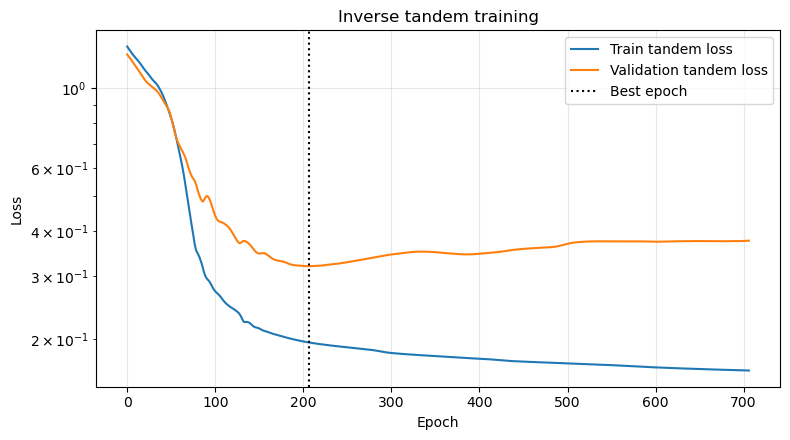

In [5]:
inverse_model = TandemInverseNet(
    inverse_features_scaled.shape[1],
    len(variable_geometry_columns),
).to(device)

X_train_device = X_train.to(device)
X_val_device = X_val.to(device)
y_train_device = y_train.to(device)
y_val_device = y_val.to(device)
curve_train_device = curve_train.to(device)
curve_val_device = curve_val.to(device)

optimizer = torch.optim.AdamW(
    inverse_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)
geometry_loss_function = nn.MSELoss()
cycle_weight = 1.0
max_epochs = 4000
patience_limit = 500

best_val_loss = float("inf")
best_epoch = 0
best_state = None
patience = 0
train_losses = []
val_losses = []

for epoch in range(max_epochs):
    inverse_model.train()
    optimizer.zero_grad()

    predicted_geometry = inverse_model(X_train_device)
    reconstructed_curve = forward_from_scaled_geometry(
        predicted_geometry
    )
    train_loss = geometry_loss_function(
        predicted_geometry,
        y_train_device,
    ) + cycle_weight * weighted_curve_loss(
        reconstructed_curve,
        curve_train_device,
    )
    train_loss.backward()
    optimizer.step()

    inverse_model.eval()
    with torch.no_grad():
        val_geometry = inverse_model(X_val_device)
        val_reconstructed_curve = forward_from_scaled_geometry(
            val_geometry
        )
        val_loss = geometry_loss_function(
            val_geometry,
            y_val_device,
        ) + cycle_weight * weighted_curve_loss(
            val_reconstructed_curve,
            curve_val_device,
        )

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss - 1e-7:
        best_val_loss = val_loss.item()
        best_epoch = epoch + 1
        best_state = copy.deepcopy(inverse_model.state_dict())
        patience = 0
    else:
        patience += 1

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(
            f"epoch={epoch + 1:04d}, train={train_loss.item():.6f}, "
            f"val={val_loss.item():.6f}"
        )

    if patience >= patience_limit:
        print(f"Early stopping at epoch {epoch + 1}")
        break

inverse_model.load_state_dict(best_state)
print(f"最佳 epoch: {best_epoch}")

plt.figure(figsize=(8, 4.5))
plt.plot(train_losses, label="Train tandem loss")
plt.plot(val_losses, label="Validation tandem loss")
plt.axvline(
    best_epoch - 1,
    color="black",
    linestyle=":",
    label="Best epoch",
)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Inverse tandem training")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
inverse_model.eval()
with torch.no_grad():
    all_scaled_geometry = inverse_model(
        torch.tensor(
            inverse_features_scaled,
            dtype=torch.float32,
            device=device,
        )
    )
    cycle_curves_db = forward_from_scaled_geometry(
        all_scaled_geometry
    ).cpu().numpy()

predicted_geometry = (
    all_scaled_geometry.cpu().numpy() * geometry_span + geometry_min
)
geometry_absolute_error = np.abs(predicted_geometry - geometry)

parameter_metrics = pd.DataFrame(
    {
        "Train MAE": geometry_absolute_error[train_indices].mean(axis=0),
        "Validation MAE": geometry_absolute_error[val_indices].mean(axis=0),
        "Validation RMSE": np.sqrt(
            np.mean(
                (
                    predicted_geometry[val_indices]
                    - geometry[val_indices]
                ) ** 2,
                axis=0,
            )
        ),
        "Validation R2": [
            r2_score(
                geometry[val_indices, column_index],
                predicted_geometry[val_indices, column_index],
            )
            for column_index in range(geometry.shape[1])
        ],
    },
    index=variable_geometry_columns,
)
display(parameter_metrics)

cycle_error = cycle_curves_db - curves_db
cycle_mae = np.mean(np.abs(cycle_error), axis=1)
cycle_rmse = np.sqrt(np.mean(cycle_error**2, axis=1))

true_min_index = np.argmin(curves_db, axis=1)
cycle_min_index = np.argmin(cycle_curves_db, axis=1)
rows = np.arange(len(raw_data))
cycle_summary = pd.Series(
    {
        "Validation curve MAE (dB)": cycle_mae[val_indices].mean(),
        "Validation curve median MAE (dB)": np.median(
            cycle_mae[val_indices]
        ),
        "Validation curve RMSE (dB)": cycle_rmse[val_indices].mean(),
        "Resonance frequency MAE (MHz)": (
            np.mean(
                np.abs(
                    frequency[cycle_min_index[val_indices]]
                    - frequency[true_min_index[val_indices]]
                )
            )
            * 1000
        ),
        "Resonance depth MAE (dB)": np.mean(
            np.abs(
                cycle_curves_db[rows, cycle_min_index]
                - curves_db[rows, true_min_index]
            )[val_indices]
        ),
    },
    name="Forward cycle validation",
)
display(cycle_summary.to_frame())

inverse_package = {
    "model_state": inverse_model.state_dict(),
    "variable_geometry_columns": variable_geometry_columns,
    "constant_geometry": constant_geometry,
    "geometry_min": geometry_min,
    "geometry_max": geometry_max,
    "inverse_pca_components": inverse_pca.components_,
    "inverse_pca_mean": inverse_pca.mean_,
    "inverse_feature_mean": inverse_feature_scaler.mean_,
    "inverse_feature_scale": inverse_feature_scaler.scale_,
    "frequency": frequency,
    "input_dim": inverse_features_scaled.shape[1],
    "output_dim": len(variable_geometry_columns),
}
torch.save(inverse_package, "model_inverse_tandem.pth")
print("逆向模型已保存到 model_inverse_tandem.pth")


,Train MAE,Validation MAE,Validation RMSE,Validation R2
sx,2.213674,2.568581,3.079210,0.212313
sy,2.126964,2.207719,2.647211,-0.044346
sl,0.867834,0.984054,1.180945,-0.045415
sw,1.140669,1.039525,1.374196,0.684942


,Forward cycle validation
Validation curve MAE (dB),0.447780
Validation curve median MAE (dB),0.256031
Validation curve RMSE (dB),1.077289
Resonance frequency MAE (MHz),5.179994
Resonance depth MAE (dB),4.327222


逆向模型已保存到 model_inverse_tandem.pth


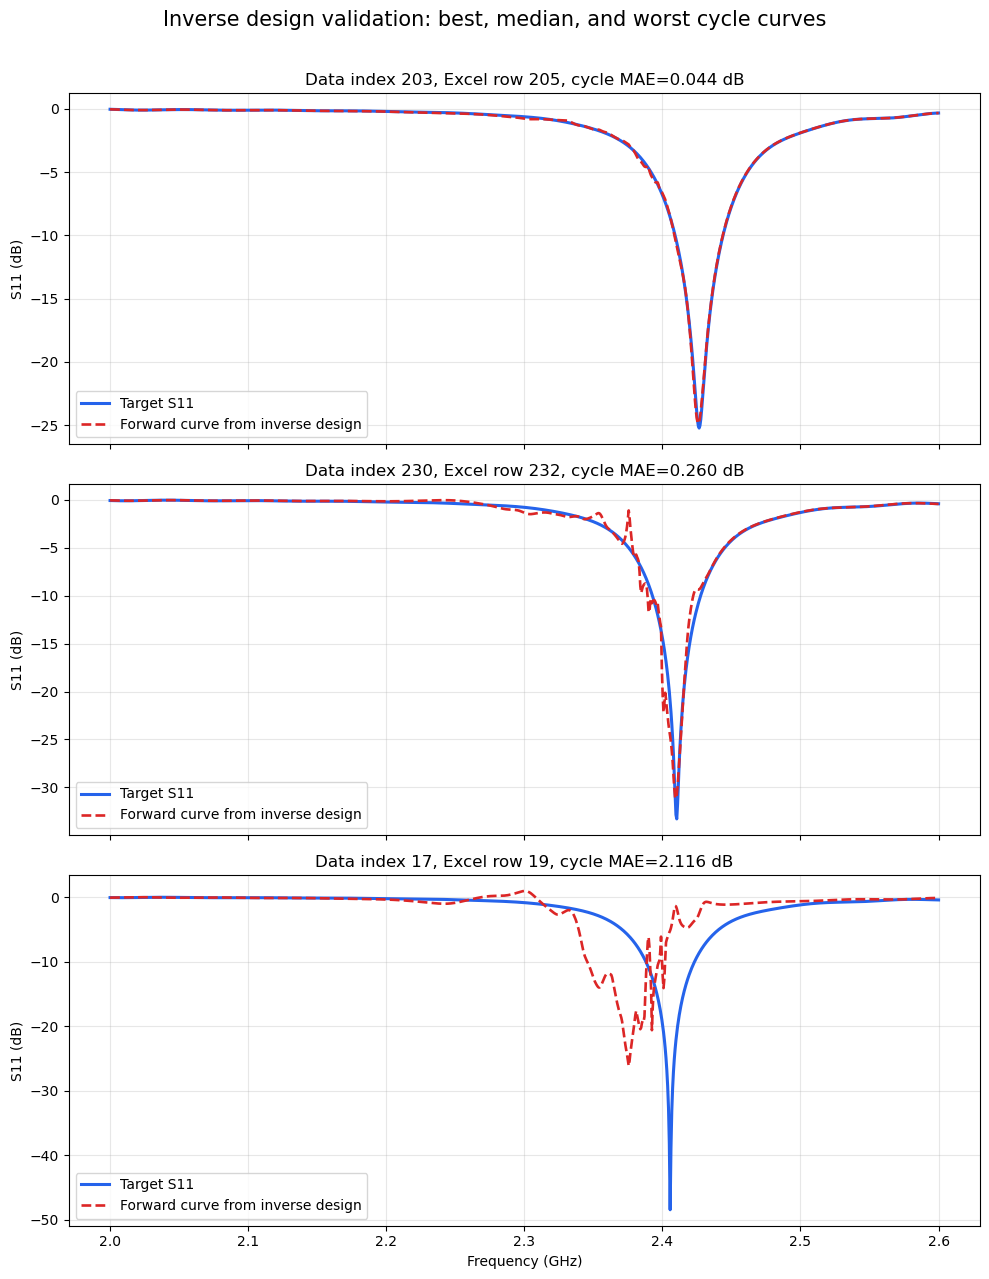

,data_index,excel_row,cycle_mae_db,true_sx,pred_sx,true_sy,pred_sy,true_sl,pred_sl,true_sw,pred_sw
0,203,205,0.044268,9.0,9.647386,9.0,4.721262,4.6,3.148173,2.5,2.744916
1,230,232,0.260187,7.0,5.919637,3.0,3.859014,2.2,3.334686,5.5,4.943662
2,17,19,2.116324,1.5,7.008519,2.0,4.227554,4.4,4.498204,4.0,8.134877


In [7]:
# 选择验证集中回代曲线表现最好、中等、最差的三个样本。
ordered_validation = val_indices[
    np.argsort(cycle_mae[val_indices])
]
representative_indices = [
    int(ordered_validation[0]),
    int(ordered_validation[len(ordered_validation) // 2]),
    int(ordered_validation[-1]),
]

figure, axes = plt.subplots(3, 1, figsize=(10, 13), sharex=True)
comparison_rows = []

for axis, sample_index in zip(axes, representative_indices):
    axis.plot(
        frequency,
        curves_db[sample_index],
        color="#2563EB",
        linewidth=2.2,
        label="Target S11",
    )
    axis.plot(
        frequency,
        cycle_curves_db[sample_index],
        color="#DC2626",
        linewidth=1.9,
        linestyle="--",
        label="Forward curve from inverse design",
    )
    axis.set_title(
        f"Data index {sample_index}, Excel row {sample_index + 2}, "
        f"cycle MAE={cycle_mae[sample_index]:.3f} dB"
    )
    axis.set_ylabel("S11 (dB)")
    axis.grid(alpha=0.3)
    axis.legend()

    row = {
        "data_index": sample_index,
        "excel_row": sample_index + 2,
        "cycle_mae_db": cycle_mae[sample_index],
    }
    for column_index, column in enumerate(
        variable_geometry_columns
    ):
        row[f"true_{column}"] = geometry[
            sample_index,
            column_index,
        ]
        row[f"pred_{column}"] = predicted_geometry[
            sample_index,
            column_index,
        ]
    comparison_rows.append(row)

axes[-1].set_xlabel("Frequency (GHz)")
figure.suptitle(
    "Inverse design validation: best, median, and worst cycle curves",
    fontsize=15,
)
figure.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

display(pd.DataFrame(comparison_rows))


数据索引=203, Excel 行号=205, 正向回代曲线 MAE=0.044 dB


,True,Predicted,Absolute error
L,39.6,39.600000,0.000000
W,39.6,39.600000,0.000000
Q,4.0,4.000000,0.000000
sx,9.0,9.647386,0.647386
sy,9.0,4.721262,4.278738
sl,4.6,3.148173,1.451827
sw,2.5,2.744916,0.244916


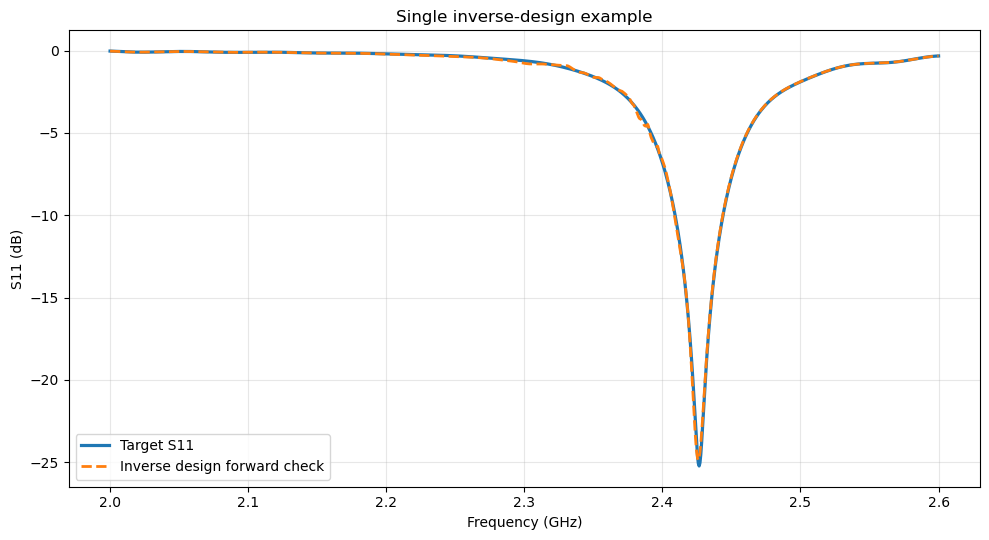

In [8]:
# 单独测试一条曲线。修改 sample_index 可检查其他行。
sample_index = int(val_indices[0])

full_true_geometry = all_geometry.iloc[sample_index].copy()
full_predicted_geometry = full_true_geometry.copy()
for column_index, column in enumerate(variable_geometry_columns):
    full_predicted_geometry[column] = predicted_geometry[
        sample_index,
        column_index,
    ]

single_comparison = pd.DataFrame(
    {
        "True": full_true_geometry,
        "Predicted": full_predicted_geometry,
        "Absolute error": np.abs(
            full_predicted_geometry - full_true_geometry
        ),
    }
)

print(
    f"数据索引={sample_index}, Excel 行号={sample_index + 2}, "
    f"正向回代曲线 MAE={cycle_mae[sample_index]:.3f} dB"
)
display(single_comparison)

plt.figure(figsize=(10, 5.5))
plt.plot(
    frequency,
    curves_db[sample_index],
    linewidth=2.3,
    label="Target S11",
)
plt.plot(
    frequency,
    cycle_curves_db[sample_index],
    "--",
    linewidth=2,
    label="Inverse design forward check",
)
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (dB)")
plt.title("Single inverse-design example")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
print(
    "注意：逆向问题可能存在多解。预测尺寸与原始尺寸不完全相同，"
    "但正向回代曲线接近目标时，该尺寸仍可能是有效的替代设计。"
)


注意：逆向问题可能存在多解。预测尺寸与原始尺寸不完全相同，但正向回代曲线接近目标时，该尺寸仍可能是有效的替代设计。


## 多组候选逆向解

连续尺寸空间可能存在无限多个近似解。下面使用多起点优化搜索，输出曲线误差小且尺寸彼此不同的候选方案。候选结果基于正向代理模型，最终仍需使用 CST/HFSS 等电磁仿真验证。


In [ ]:
import os
import runpy

# 修改该索引可为其他 Excel 数据行搜索多组候选解。
candidate_sample_index = 0
os.environ["INVERSE_TARGET_INDEX"] = str(candidate_sample_index)
runpy.run_path("search_inverse_candidates.py", run_name="__main__")

candidate_solutions = pd.read_csv("inverse_candidate_solutions.csv")
display(candidate_solutions)
print("候选曲线图已保存到 inverse_candidate_solutions.png")
